# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [13]:
ПІБ = 'Колбасюк Данило Іванович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-32'      # напр. 'КН-31'
ВАРІАНТ = 6     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [14]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Колбасюк Данило Іванович, ШІ-32, варіант 6
ваш потік:                   P>30
ваша пара для графіка 3:     густина вітру та потік P>1
ваш агрегат для етапу 4:     мінімум
ваше додаткове питання:      У яку добу середнє значення вашого потоку було найбільшим? А найменшим?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)* При читанні ми не обробили самі дані, тому вивелась повна таблиця, неназвані стовпчики відповідно Unnamed: #, а пусті клітинки - NaN. 

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [16]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, header=None)
print(RAW.shape)
print(RAW.head(30))


(7226, 32)
    0                                                  1    2    3     4         5        6      7      8      9       10      11      12     13     14  15  \
0  NaN        ftp://ftp.swpc.noaa.gov/pub/lists/particle/  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
1  NaN                                                NaN  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
2  NaN                :Data_list: 20170901_Gs_part_5m.txt  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
3  NaN                     :Created: 2017 Sep 02 0011 UTC  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
4  NaN  # Prepared by the U.S. Dept. of Commerce, NOAA...  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
5  NaN  # Please send comments and 

### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [17]:
# ВАШ КОД
print(RAW.notna().sum())

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** Глянемо на 'пропуски' в згустках (нулі), по них бачимо, що є 3 таблиці, в першій 13 стовпчиків (2-14), в другій 4 стовпчика (17-20), в третій 8 стовпчиків (25-32)

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [18]:
print(RAW.iloc[0:20,1]) # Таблиця 1
print(RAW.iloc[13:20,16]) # Таблиця 2
print(RAW.iloc[0:7,26]) # Таблиця 3

0           ftp://ftp.swpc.noaa.gov/pub/lists/particle/
1                                                   NaN
2                   :Data_list: 20170901_Gs_part_5m.txt
3                        :Created: 2017 Sep 02 0011 UTC
4     # Prepared by the U.S. Dept. of Commerce, NOAA...
5     # Please send comments and suggestions to SWPC...
6                                                    # 
7                  # Label: P > 1 = Particles at >1 Mev
8                  # Label: P > 5 = Particles at >5 Mev
9                 # Label: P >10 = Particles at >10 Mev
10                # Label: P >30 = Particles at >30 Mev
11                # Label: P >50 = Particles at >50 Mev
12               # Label: P>100 = Particles at >100 Mev
13               # Label: E>0.8 = Electrons at >0.8 Mev
14               # Label: E>2.0 = Electrons at >2.0 Mev
15               # Label: E>4.0 = Electrons at >4.0 Mev
16                # Units: Particles = Protons/cm2-s-sr
17              # Units: Electrons = Electrons/c

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | ftp://ftp.swpc.noaa.gov/pub/lists/particle/ | Частинки = Протони/cm2\*s\*sr, Електрони = Eлектрони/cm2\*s\*sr |
| B | ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt | Radio Flux 10.7 в певний час |
| C | http://umtof.umd.edu/pm/crn/ | км/с, протони на cm^3 |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [19]:
A = RAW.iloc[26:7226, 1:15]
B = RAW.iloc[27:52, 16:20]
C = RAW.iloc[27:628, 24:32]
A.columns = ['year', 'month', 'day', 'hhmm', 'Modified Julian Day', 'Seconds of the day', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']
B.columns = ['year', 'month', 'day', 'Radio Flux 10.7']
C.columns = ['hour1', 'hour2', 'year', 'month', 'day', 'hour', 'Speed', 'Density']
C=C.drop(columns=['hour1','hour2'])
A=A.apply(pd.to_numeric, errors='coerce')
B=B.apply(pd.to_numeric, errors='coerce')
C=C.apply(pd.to_numeric, errors='coerce')

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [20]:
A['ts'] = pd.to_datetime(
    A['year'].astype(str) + "-" +
    A['month'].astype(str) + "-" +
    A['day'].astype(str) + " " +
    A['hhmm'].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M",
    errors="coerce"
)
A=A.drop(columns=['year', 'month', 'day', 'hhmm', 'Modified Julian Day', 'Seconds of the day'])
B['ts']=pd.to_datetime(B[['year','month','day']])
B=B.drop(columns=['year','month','day'])
C['year']=C['year']+2000
C['ts']=pd.to_datetime(C[['year','month','day','hour']])
C=C.drop(columns=['year','month','day','hour'])
print(A['ts'].min())
print(A['ts'].max())
print(B['ts'].min())
print(B['ts'].max())
print(C['ts'].min())
print(C['ts'].max())

2017-08-28 00:00:00
2017-09-21 23:55:00
2017-08-28 00:00:00
2017-09-21 00:00:00
2017-08-28 00:00:00
2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [21]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [22]:
print(A.shape)
print(A.dtypes)
print(A.isna().sum())
print(A.duplicated().sum())
print(A.describe())
print(B.shape)
print(B.dtypes)
print(B.isna().sum())
print(B.duplicated().sum())
print(B.describe())
print(C.shape)
print(C.dtypes)
print(C.isna().sum())
print(C.duplicated().sum())
print(C.describe())

(7200, 9)
P>1             float64
P>5             float64
P>10            float64
P>30            float64
P>50            float64
P>100           float64
E>0.8           float64
E>2.0           float64
ts       datetime64[us]
dtype: object
P>1      3
P>5      3
P>10     3
P>30     3
P>50     3
P>100    3
E>0.8    3
E>2.0    3
ts       0
dtype: int64
0
                P>1          P>5         P>10         P>30         P>50       P>100          E>0.8          E>2.0                   ts
count   7197.000000  7197.000000  7197.000000  7197.000000  7197.000000  7197.00000    7197.000000    7197.000000                 7200
mean     689.325064   156.626057    76.474020    18.838604     7.446840     1.65929   81862.741801   11401.502123  2017-09-09 11:57:30
min        0.429000     0.151000     0.117000     0.057600     0.045500     0.02240       4.300000       0.133000  2017-08-28 00:00:00
25%       11.700000     0.279000     0.186000     0.098400     0.059700     0.02630   22200.000000     552

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [23]:
print("Before replacement")
print((C['Speed']==-1).sum())
print((C['Density']==-1).sum())
print(f"Speed mean: {C['Speed'].mean()}")
print(f"Speed minimum: {C['Speed'].min()}")
print(f"Density mean: {C['Density'].mean()}")
print(f"Density minimum: {C['Density'].min()}")
C['Density']=C['Density'].replace(-1,np.nan)
C['Speed']=C['Speed'].replace(-1,np.nan)
print("After replacement")
print((C['Speed']==-1).sum())
print((C['Density']==-1).sum())
print(f"Speed mean: {C['Speed'].mean()}")
print(f"Speed minimum: {C['Speed'].min()}")
print(f"Density mean: {C['Density'].mean()}")
print(f"Density minimum: {C['Density'].min()}")


Before replacement
8
8
Speed mean: 506.5474209650582
Speed minimum: -1
Density mean: 2.9076539101497505
Density minimum: -1.0
After replacement
0
0
Speed mean: 513.3946037099494
Speed minimum: 277.0
Density mean: 2.960370994940978
Density minimum: 0.1


**Відповідь 3.2:** -1 означає втрачені дані, таких було 8 рядків і вони робили середнє меншим, ніж воно є насправді.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [24]:
A.describe()

,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,ts
count,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN


**Відповідь 3.3:** Це стосується стовпців часу. Середнє/стандартне відхилення якщо і обчислюється, то потім не зрозуміло, як його використати.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [25]:
flux_cols = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100',
             'E>0.8', 'E>2.0']

A_hourly = A.set_index('ts')[flux_cols].resample('1h').agg(['mean', 'max'])
A_hourly.columns = [f'{col}_{stat}' for col, stat in A_hourly.columns]
A_hourly = A_hourly.reset_index()
A_hourly


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,2017-09-21 19:00:00,63.166667,93.10,0.372500,0.795,0.229833,0.472,0.110642,0.1570,0.074300,0.1050,0.040192,0.0687,180250.000000,186000.0,65750.000000,66800.0
596,2017-09-21 20:00:00,42.102500,78.90,0.397500,0.833,0.226833,0.429,0.089325,0.1380,0.069983,0.1050,0.039692,0.0737,178750.000000,186000.0,63175.000000,70500.0
597,2017-09-21 21:00:00,50.783333,71.70,0.489250,0.788,0.317583,0.501,0.121358,0.2040,0.077467,0.1470,0.033417,0.0524,175833.333333,177000.0,58350.000000,60300.0
598,2017-09-21 22:00:00,39.000000,48.80,0.350000,0.536,0.200250,0.310,0.094358,0.1430,0.070633,0.1080,0.039600,0.0798,167750.000000,176000.0,49366.666667,54400.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

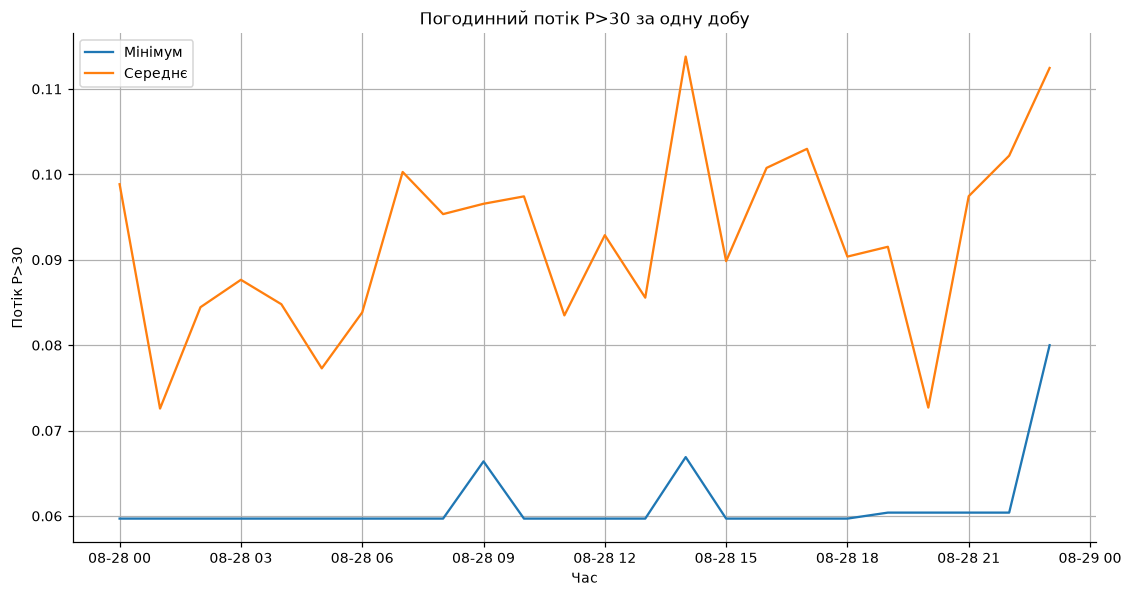

In [26]:
day = A[A['ts'].dt.date == A['ts'].dt.date.iloc[0]].copy()
hourly = (day.set_index('ts')['P>30'].resample('1h').agg(['min', 'mean']))
plt.figure(figsize=(12, 6))
plt.plot(hourly.index, hourly['min'], label='Мінімум')
plt.plot(hourly.index, hourly['mean'], label='Середнє')
plt.xlabel('Час')
plt.ylabel('Потік P>30')
plt.title('Погодинний потік P>30 за одну добу')
plt.legend()
plt.grid(True)
plt.show()


**Відповідь 4.2:** В цьому випадку, мінімум значно нижчий за середнє. Це показує, що потік був досить нестабільним. Це важливо, коли нам потрібно бачити якісь коливання в значеннях, а маючи тільки середнє чи мінімум (або іншу комбінацію агрегатів), ми б ці дані не отримали.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [27]:
B_hourly = (B.set_index('ts').resample('1h').ffill().reset_index())
M=(A_hourly.merge(C, on='ts', how='outer').merge(B_hourly, on='ts', how='outer').sort_values('ts'))

print("Розмір M:", M.shape)
print("\nРядки з пропусками:")
print(M[M.isna().any(axis=1)])


Розмір M: (601, 20)

Рядки з пропусками:
                     ts   P>1_mean  P>1_max  P>5_mean  P>5_max  P>10_mean  P>10_max  P>30_mean  P>30_max  P>50_mean  P>50_max  P>100_mean  P>100_max     E>0.8_mean  E>0.8_max    E>2.0_mean  \
175 2017-09-04 07:00:00   6.465833    10.10  0.262083    0.593   0.171500     0.294   0.085483     0.145   0.068558    0.1340    0.031717     0.0523   90600.000000   100000.0   7410.833333   
176 2017-09-04 08:00:00   4.010833     5.08  0.256000    0.432   0.195833     0.336   0.086625     0.145   0.070033    0.1340    0.036492     0.0546   73483.333333    79300.0   5048.333333   
177 2017-09-04 09:00:00   3.268333     4.42  0.303417    0.518   0.220333     0.302   0.105925     0.162   0.081975    0.1340    0.046483     0.0765   60475.000000    68500.0   3715.833333   
178 2017-09-04 10:00:00   3.179167     4.74  0.252167    0.372   0.181833     0.280   0.101900     0.150   0.081675    0.1200    0.054125     0.0894   64383.333333    68400.0   4122.500000   

**Відповідь 4.3:** 601 рядок для outer, 577 рядків для inner. Обираю outer, бо для inner деякі дані втрачаються через пропуски в клітинках.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [28]:
M['група'] = pd.cut(M['P>10_max'],bins=[-float('inf'), 10, 1000, float('inf')],labels=['тиха', 'активна', 'дуже активна'],right=False)
print(M['група'].value_counts())
M[M['група'] == 'дуже активна']

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,Speed,Density,Radio Flux 10.7,група
330,2017-09-10 18:00:00,1937.500000,2260.0,951.916667,1150.0,834.750000,1010.0,289.833333,356.0,124.916667,153.0,38.325000,44.9,166416.666667,171000.0,11941.666667,12400.0,469.0,0.9,100.0,дуже активна
334,2017-09-10 22:00:00,2770.000000,3500.0,1415.000000,1540.0,1019.916667,1070.0,349.083333,377.0,171.250000,191.0,52.933333,61.5,148000.000000,167000.0,11500.000000,14600.0,552.0,2.6,100.0,дуже активна
336,2017-09-11 00:00:00,4891.666667,6400.0,1660.833333,1920.0,1102.916667,1230.0,366.166667,398.0,172.333333,185.0,48.850000,51.7,144500.000000,152000.0,11150.833333,13100.0,566.0,4.8,80.0,дуже активна
337,2017-09-11 01:00:00,3895.000000,5350.0,1823.333333,1960.0,1167.500000,1230.0,387.083333,399.0,180.833333,185.0,50.041667,51.2,104200.000000,129000.0,6556.666667,9310.0,575.0,3.2,80.0,дуже активна
338,2017-09-11 02:00:00,3224.166667,3480.0,1672.500000,1760.0,1086.666667,1110.0,376.916667,384.0,177.750000,180.0,48.100000,49.3,98750.000000,116000.0,5792.500000,7060.0,564.0,4.0,80.0,дуже активна
339,2017-09-11 03:00:00,2970.833333,3110.0,1616.666667,1690.0,1080.833333,1120.0,377.333333,388.0,174.666667,178.0,44.275000,45.7,101900.000000,109000.0,6407.500000,6720.0,557.0,4.6,80.0,дуже активна
340,2017-09-11 04:00:00,2975.000000,3540.0,1797.500000,2030.0,1071.666667,1100.0,363.666667,372.0,167.583333,171.0,41.425000,42.9,77733.333333,92100.0,4571.666667,5870.0,556.0,3.6,80.0,дуже активна
341,2017-09-11 05:00:00,3726.666667,4010.0,2120.833333,2240.0,1144.166667,1200.0,365.333333,374.0,162.833333,165.0,38.125000,40.2,52458.333333,60200.0,3320.833333,3680.0,556.0,4.3,80.0,дуже активна
342,2017-09-11 06:00:00,3605.833333,3860.0,1993.333333,2120.0,1114.166667,1150.0,356.916667,363.0,155.166667,158.0,34.741667,35.8,40491.666667,46800.0,2438.333333,2760.0,558.0,4.5,80.0,дуже активна
343,2017-09-11 07:00:00,3469.166667,3600.0,1903.333333,1960.0,1082.500000,1100.0,345.666667,351.0,146.916667,151.0,31.733333,33.2,38700.000000,46100.0,2655.833333,3160.0,556.0,4.2,80.0,дуже активна


**Самоперевірка етапу 4.**

In [29]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє: 18.831272835858584
Медіана: 0.137825


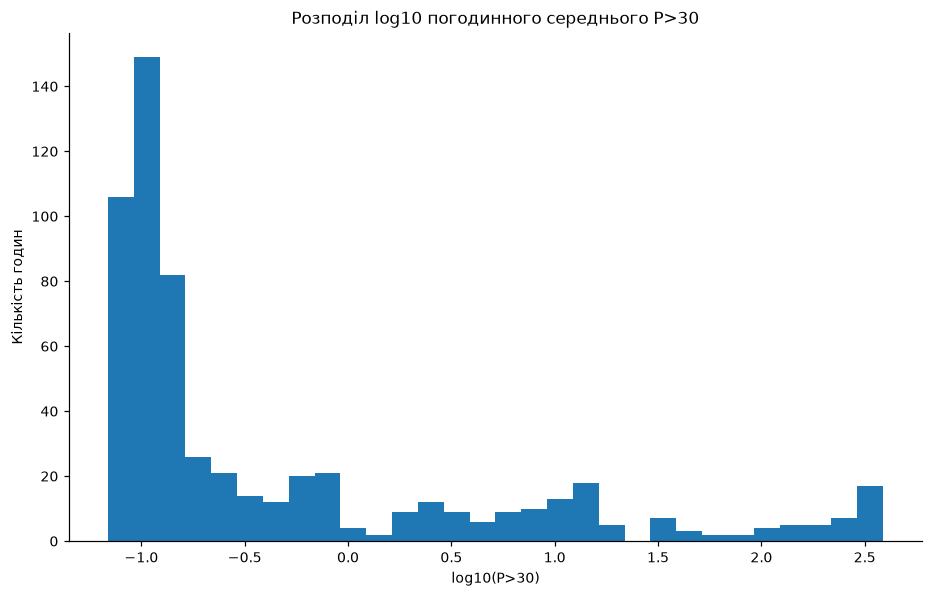

In [30]:
print("Середнє:", M['P>30_mean'].mean())
print("Медіана:", M['P>30_mean'].median())
P30=M['P>30_mean']
P30_positive=P30[P30 > 0]
P30_log=np.log10(P30_positive)

plt.figure(figsize=(10, 6))
plt.hist(P30_log, bins=30)

plt.xlabel('log10(P>30)')
plt.ylabel('Кількість годин')
plt.title('Розподіл log10 погодинного середнього P>30')

plt.show()


**Висновок:** В основному значення потоку є дуже малими, але через деякі великі значення середнє стає набагато більшим, ніж медіана.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

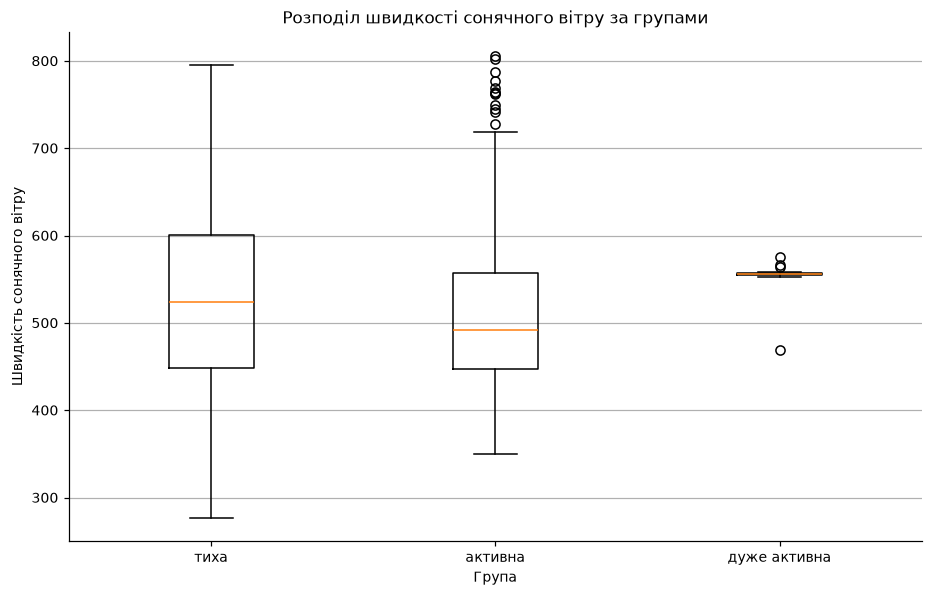

In [31]:
groups = ['тиха', 'активна', 'дуже активна']
data = [
    M.loc[M['група'] == group, 'Speed'].dropna()
    for group in groups
]

plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=groups)

plt.xlabel('Група')
plt.ylabel('Швидкість сонячного вітру')
plt.title('Розподіл швидкості сонячного вітру за групами')
plt.grid(axis='y')
plt.show()

**Висновок:** Відрізняється, в кожної групи свій діапазон швидкості вітру.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

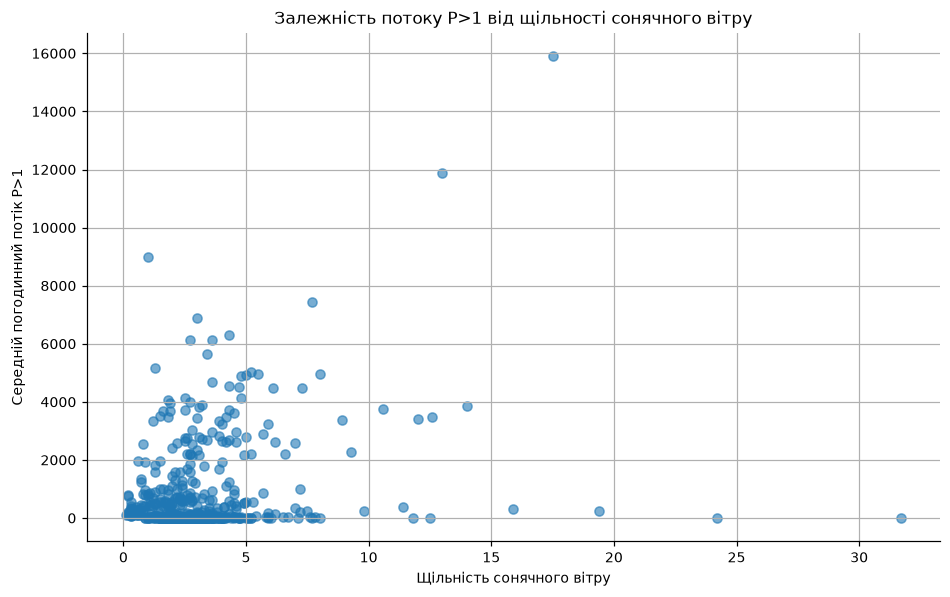

Коефіцієнт кореляції: 0.28528892999766575


In [32]:
data = M[['Density', 'P>1_mean']].dropna()
plt.figure(figsize=(10, 6))
plt.scatter(data['Density'], data['P>1_mean'], alpha=0.6)
plt.xlabel('Щільність сонячного вітру')
plt.ylabel('Середній погодинний потік P>1')
plt.title('Залежність потоку P>1 від щільності сонячного вітру')
plt.grid(True)
plt.show()
correlation = data['Density'].corr(data['P>1_mean'])
print('Коефіцієнт кореляції:', correlation)

**Висновок:** Є кореляція в позитивний бік.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

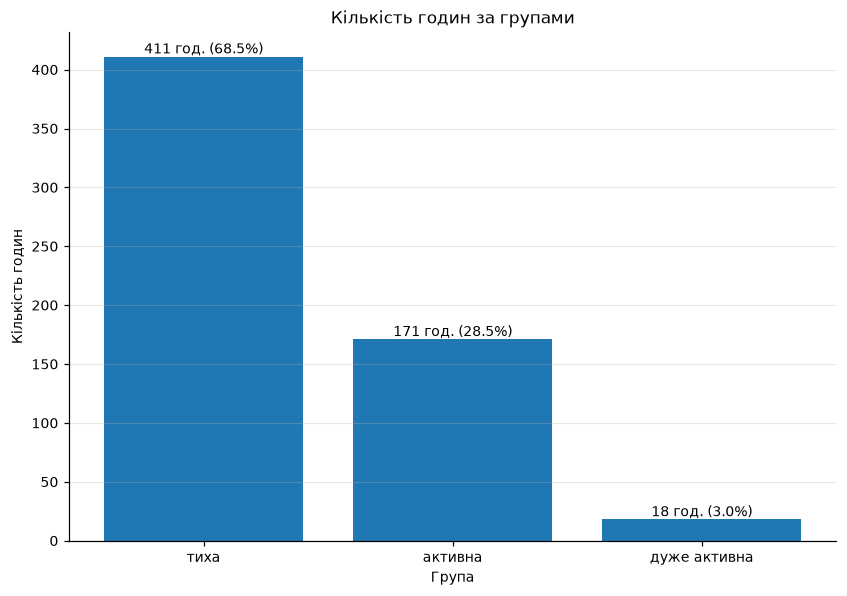

In [33]:
counts = (M['група'].value_counts().reindex(groups, fill_value=0))
total = counts.sum()
percent = counts / total * 100
plt.figure(figsize=(9, 6))
bars = plt.bar(groups, counts)
for bar, count, pct in zip(bars, counts, percent):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count} год. ({pct:.1f}%)',
        ha='center',
        va='bottom'
    )
plt.xlabel('Група')
plt.ylabel('Кількість годин')
plt.title('Кількість годин за групами')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Висновок:** Набагато більше годин в тихій групі (411). Активна група має 171 годину, а дуже активна - дуже мала група (тільки 18 годин)  

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

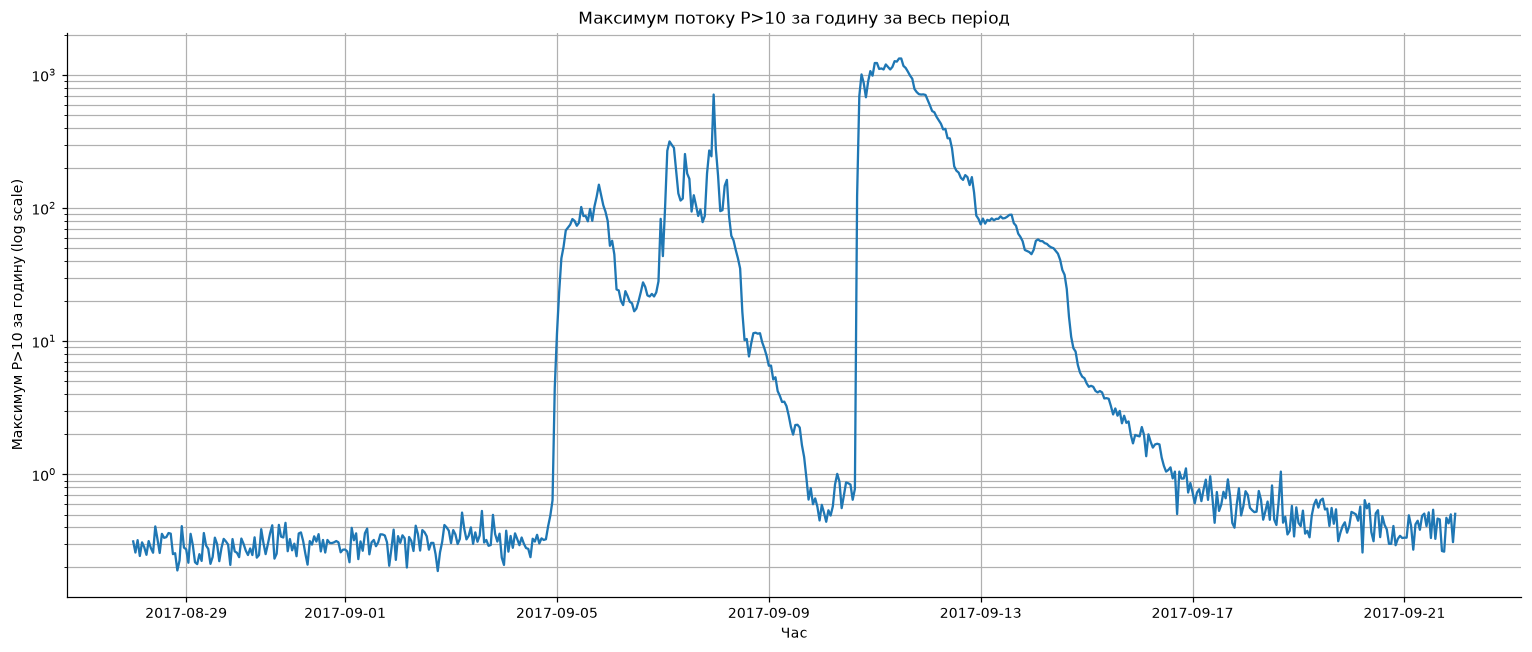

In [34]:
data = M[['ts', 'P>10_max']].dropna()
data = data[data['P>10_max'] > 0]

plt.figure(figsize=(14, 6))
plt.plot(data['ts'], data['P>10_max'])

plt.yscale('log')

plt.xlabel('Час')
plt.ylabel('Максимум P>10 за годину (log scale)')
plt.title('Максимум потоку P>10 за годину за весь період')
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

**Висновок:** Спостерігалась висока сонячна активність від 5 вересня до 9 вересня та від 10 вересня до 17 вересня 2017 року. Поза цими датами сонячна активність залишалась низькою.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

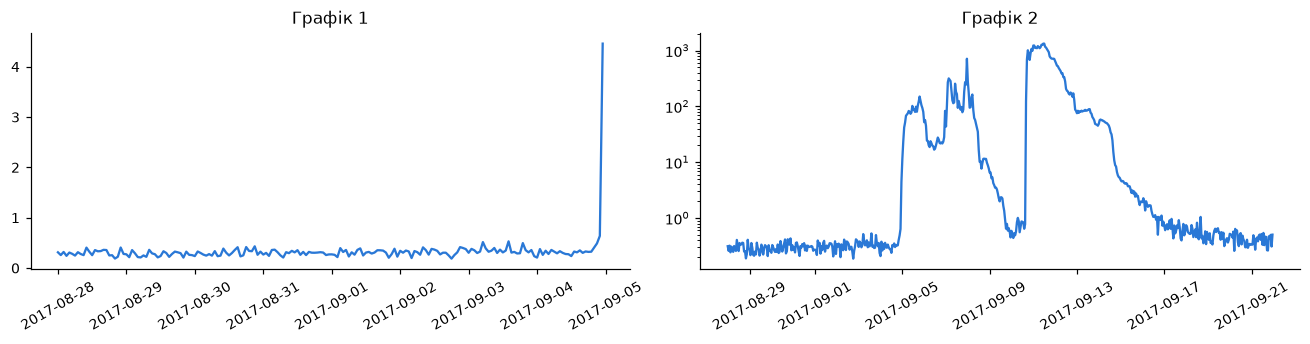

In [35]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: активність набагато збільшилась (в 7-8 разів) від 5 вересня 2017 року
2. Висновок з другого графіка: активність була досить низькою, крім 5-9 та 10-14 вересня 2017 року
3. Дві відмінності між ними: діапазон дат, масштаб показу даних.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

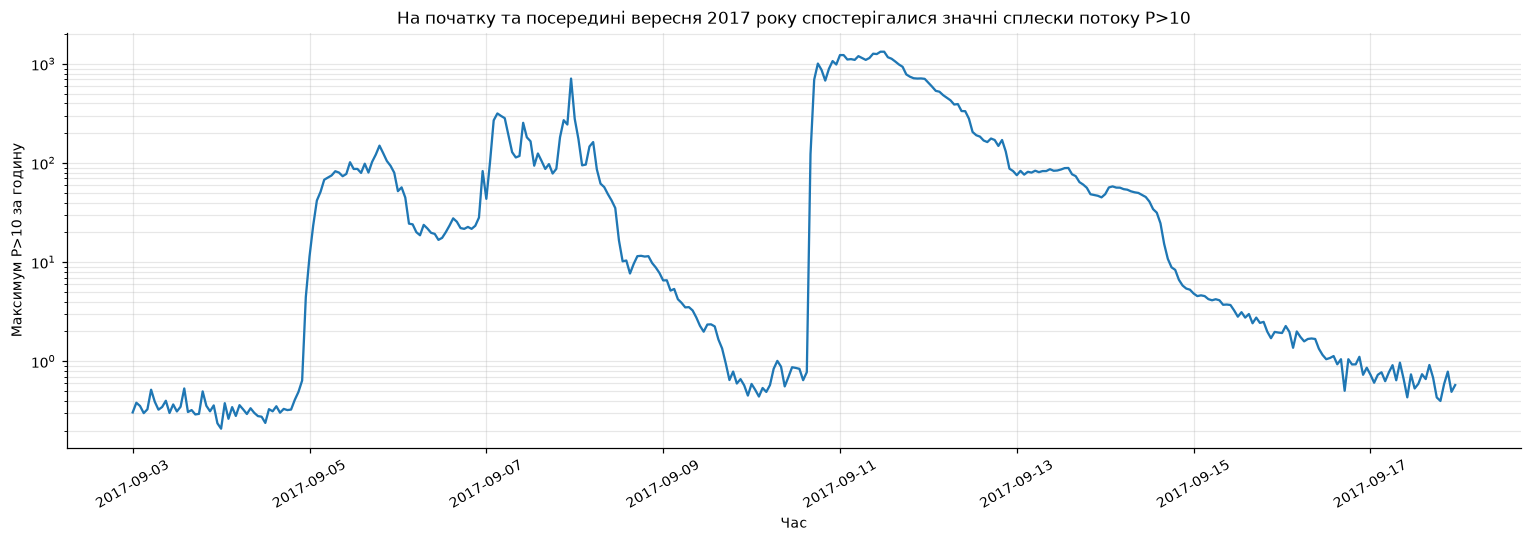

In [36]:
вікно = M[
    (M['ts'] >= '2017-09-03') &
    (M['ts'] < '2017-09-18')
].copy()
вікно = вікно[вікно['P>10_max'] > 0]
plt.figure(figsize=(14, 5))
plt.plot(
    вікно['ts'],
    вікно['P>10_max']
)
plt.yscale('log')

plt.xlabel('Час')
plt.ylabel('Максимум P>10 за годину')
plt.title('На початку та посередині вересня 2017 року спостерігалися значні сплески потоку P>10')

plt.xticks(rotation=30)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


**Відповідь 6.2:** Логарифмізація значень допомагає краще показати коливання значень протягом певних періодів часу (значення стискаються). Протягом саме цього діапазону часу відбуваються сплески, і можна показати де вони почались та закінчились.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Було тільки 18 годин, протягом яких спостерігався дуже активний потік P>10 (P>10_max>1000), причому всі з них спостерігались в межах одної доби (2017-09-10 18:00:00 - 2017-09-11 18:00:00). Код - завдання 4.4

**Спостереження 2:** В активній групі дуже багато нетипових значень швидкості вітру (700-800). Код - завдання 5, графік 2

**Спостереження 3:** Найменші значення потоку в P>100, причому набагато менші, ніж в інших потоків. Код - завдання 3.3


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [37]:
daily_P30 = (
    M.assign(date=M['ts'].dt.date)
     .groupby('date')['P>30_mean']
     .mean()
)

print("Найбільше:", daily_P30.idxmax(), daily_P30.max())
print("Найменше:", daily_P30.idxmin(), daily_P30.min())

Найбільше: 2017-09-11 292.93055555555554
Найменше: 2017-09-01 0.08973368055555557


**Відповідь 7.2:** 11 вересня 2017 року спостерігалось найбільше середнє значення потоку P>30, 1 вересня - найменше.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [38]:
ІНСТРУМЕНТИ_ШІ = 'ChatGPT'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'ні',
    'етапи 6–7, порівняння графіків і спостереження': 'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'Знайшов помилку для підпису колонок під графіком коробок (бот написав "labels" замість "tick_labels"). Також перевірив будову графіків.'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [39]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Колбасюк Данило Іванович
інструменти:                                   ChatGPT
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                ні
етапи 6–7, порівняння графіків і спостереження: код, перевірено
------------------------------------------------------------------------------
перевірено автором:
Знайшов помилку для підпису колонок під графіком коробок (бот написав "labels" замість "tick_labels"). Також перевірив будову графіків.
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [40]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 21)


In [41]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
